In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import torch

In [3]:
device = torch.device('cpu') if not torch.accelerator.is_available() else torch.accelerator.current_accelerator()
print(device)

cuda


# Hyperparameters

In [4]:
batch_size = 128
resize = (96, 96)
num_epochs = 10
lr = 0.001

# Load dataset

In [5]:
from utils.data import CIFAR10
from utils.train import train_model, val_stats

def get_optimizer(model):
    return torch.optim.Adam(model.parameters(), lr=lr)

def fit(model, num_epochs=num_epochs):
    dataset = CIFAR10(batch_size=batch_size, resize=resize, device=device)
    train_dl, val_dl = dataset.get_dataloaders()
    optimizer = get_optimizer(model)
    return train_model(model, train_dl, val_dl, optimizer, num_epochs)

# Create model

We'll be implementing the GoogLeNet (multi-branch network) architecture here.

What makes the multi-branch network different is that convolutions of multiple sizes are used at the same layer, then concatenated together. This is called an "inception" block. The main hyperparameter in each "inception" block is the number of channels used.

In [6]:
from torch import nn
import torch.nn.functional as F
from utils.models import Module

#### Residual Block

In [7]:
class Residual(nn.Module):
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.LazyConv2d(num_channels, kernel_size=3, stride=strides,
                                   padding=1)
        self.conv2 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1)
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()
        if use_1x1conv:
            self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1, stride=strides)
        else:
            self.conv3 = None

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        return F.relu(X + Y)

In [8]:
blk = Residual(3)
X = torch.randn(4, 3, 6, 6)
print(blk(X).shape)

torch.Size([4, 3, 6, 6])


In [9]:
blk = Residual(6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

## ResNet Model

In [10]:
class ResNet(Module):
    def __init__(self, arch, num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        self.net = nn.Sequential(self.stem())
        for i, b in enumerate(arch):
            self.net.add_module(f"Block {i}", self.block(*b, is_first_block=(i==0)))
        self.net.add_module("Head", self.head())
        
    def stem(self):
        return nn.Sequential(nn.LazyConv2d(64, kernel_size=7, padding=3, stride=2),
                             nn.LazyBatchNorm2d(), nn.ReLU(),
                             nn.MaxPool2d(kernel_size=3, padding=1, stride=2))

    def block(self, num_residuals, num_channels, is_first_block=False):
        blk = nn.Sequential()
        for i in range(num_residuals):
            if i == 0 and not is_first_block:
                blk.add_module(f"Residual block {i}", Residual(num_channels, use_1x1conv=True, strides=2))
            else:
                blk.add_module(f"Residual blk {i}", Residual(num_channels))
        return blk

    def head(self):
        return nn.Sequential(nn.AdaptiveAvgPool2d((1,1)), 
                             nn.Flatten(), 
                             nn.LazyLinear(self.num_classes))

    def forward(self, X):
        return self.net(X)

In [11]:
class ResNet18(ResNet):
    def __init__(self, num_classes=10):
        arch = ((2, 64), (2, 128), (2, 256), (2, 512))
        super().__init__(arch, num_classes=num_classes)

In [12]:
model = ResNet18().to(device)
X = torch.randn(batch_size, 3, *resize).to(device)

In [13]:
with torch.no_grad():
    print(model(X).shape)

print(model)

torch.Size([128, 10])
ResNet18(
  (net): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (Block 0): Sequential(
      (Residual blk 0): Residual(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (Residual blk 1): Residual(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn1): BatchNorm

In [14]:
num_params = sum(p.numel() for p in model.parameters())
print(num_params)
print(f"Parameter memory: {num_params * 4 / 1e6:.0f} MB")

11184650
Parameter memory: 45 MB


# Train model

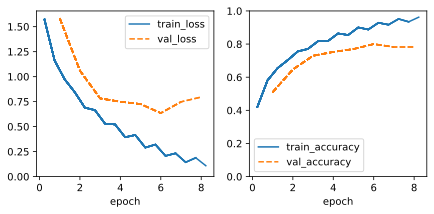

In [ ]:
fit(model);

In [21]:
_, val_dl = CIFAR10(batch_size=batch_size, resize=resize, device=device).get_dataloaders()
val_loss, val_accuracy = val_stats(model, val_dl, device=device)

In [22]:
print(f"Validation loss: {val_loss:.2f}, accuracy: {val_accuracy:.2f}%")

Validation loss: 1.11, accuracy: 0.76%


# How much memory usage during training?

In [23]:
print(f"Max memory allocated: {torch.cuda.max_memory_allocated()/1e9:.3f} GB")

Max memory allocated: 0.776 GB


# ResNeXt Block

In [24]:
class ResNeXtBlock(nn.Module):
    def __init__(self, num_channels, num_groups, bot_mul, use_1x1conv=False,
                 strides=1):
        super().__init__()
        b = int(round(num_channels * bot_mul))
        self.conv1 = nn.LazyConv2d(b, kernel_size=1, stride=1)
        self.conv2 = nn.LazyConv2d(b, kernel_size=3, 
                                   stride=strides, padding=1, 
                                   groups=b//num_groups)
        self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1, stride=1)
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()
        self.bn3 = nn.LazyBatchNorm2d()
        if use_1x1conv:
            self.conv4 = nn.LazyConv2d(num_channels, kernel_size=1, stride=strides)
            self.bn4 = nn.LazyBatchNorm2d()
        else:
            self.conv4 = None

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = F.relu(self.bn2(self.conv2(Y)))
        Y = self.bn3(self.conv3(Y))
        if self.conv4:
            X = self.bn4(self.conv4(X))
        return F.relu(X + Y)


In [25]:
blk = ResNeXtBlock(32, 16, 1)
X = torch.randn(4, 32, 96, 96)
blk(X).shape

torch.Size([4, 32, 96, 96])